<a href="https://colab.research.google.com/github/AbhiVidholiya7026/AbhiVidholiya7026/blob/main/DigitalImageProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

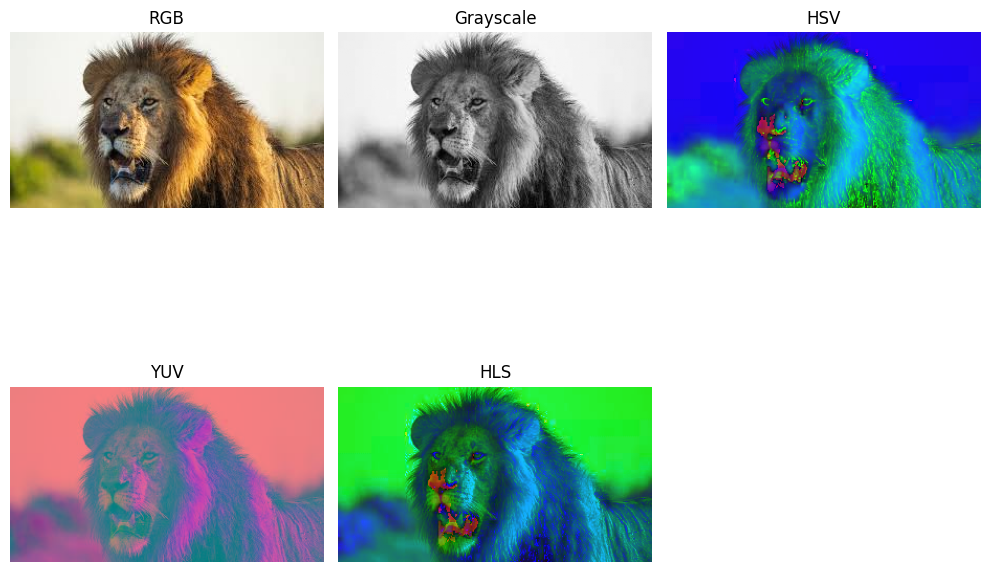

In [19]:
import cv2
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
import numpy as np

# Replace this with the path to your image file in Colab or a public URL
# Example: For a file uploaded to Colab, it might be 'img404.jpg'
# Example: For a public URL, it would be the direct URL to the image
image_source = 'img404.jpeg' # Placeholder URL

# Attempt to load the image
try:
    if image_source.startswith('http'):
        # Load image from URL
        response = requests.get(image_source)
        response.raise_for_status() # Raise an exception for bad status codes
        img = Image.open(BytesIO(response.content))
        img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR) # Convert PIL image to OpenCV format
    else:
        # Load image from local path (in Colab environment)
        img = cv2.imread(image_source)

    if img is None:
        raise FileNotFoundError(f"Image not found at {image_source}")

    # Convert image to different color spaces
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

    # Prepare images and titles for plotting
    titles = ['RGB', 'Grayscale', 'HSV', 'YUV', 'HLS']
    images = [img_rgb, gray, hsv, yuv, hls]

    # Plot the images
    plt.figure(figsize=(10, 8))
    for i in range(5):
        plt.subplot(2, 3, i+1)
        # For grayscale and other color spaces, we need to handle how imshow displays them
        if len(images[i].shape) == 2: # Grayscale
             plt.imshow(images[i], cmap='gray')
        else: # Color images
             plt.imshow(images[i])

        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading image: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

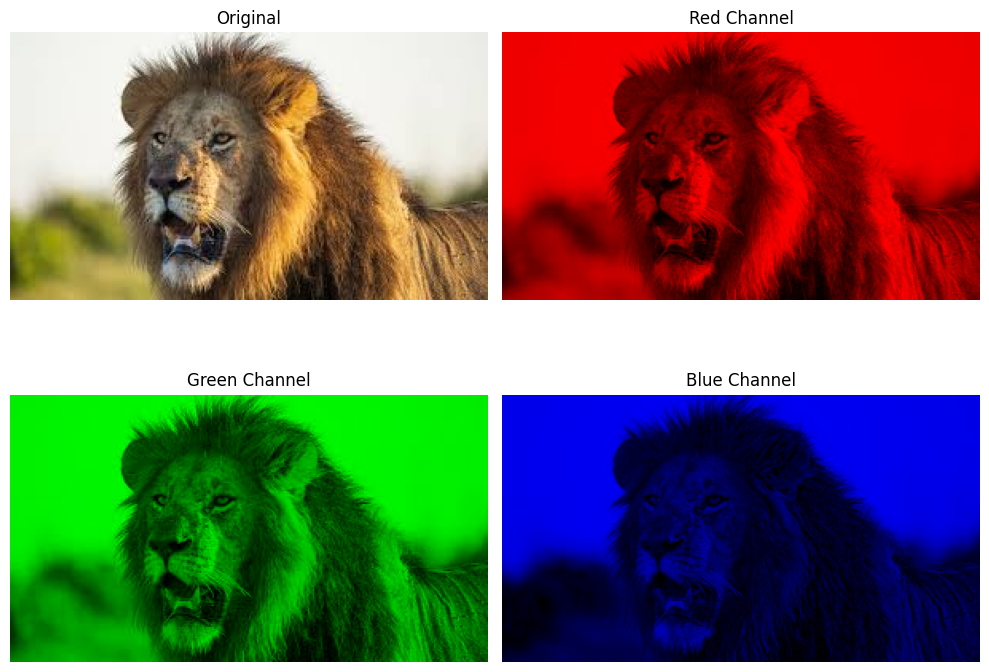

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'img' is loaded from the previous cell and is in BGR format
b, g, r = cv2.split(img)

zeros = np.zeros_like(b)

# Create images for each channel (in BGR format for consistent merging)
red_img = cv2.merge([zeros, zeros, r])
green_img = cv2.merge([zeros, g, zeros])
blue_img = cv2.merge([b, zeros, zeros])

titles = ['Original', 'Red Channel', 'Green Channel', 'Blue Channel']
# Convert original img to RGB for correct display with plt.imshow
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB), cv2.cvtColor(green_img, cv2.COLOR_BGR2RGB), cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB)]

plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

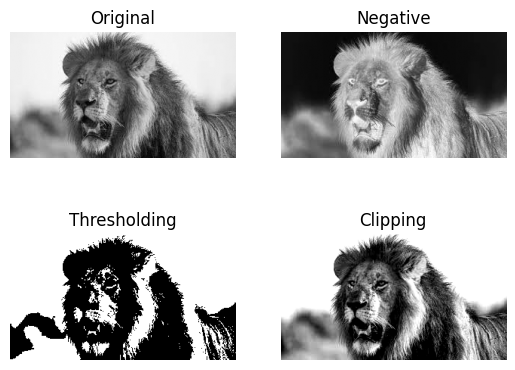

In [28]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
negative = 255 - gray
_, thresholded = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
clipped = np.clip(gray, 50, 200)


titles = ['Original', 'Negative', 'Thresholding', 'Clipping']
images = [gray, negative, thresholded, clipped]

for i in range(4):
      plt.subplot(2, 2, i+1)
      plt.imshow(images[i], cmap='gray')
      plt.title(titles[i])
      plt.axis('off')
plt.show()

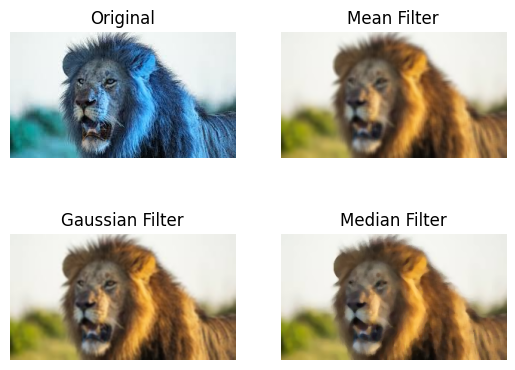

In [30]:
mean_blur = cv2.blur(img, (5, 5))
gaussian_blur = cv2.GaussianBlur(img, (5, 5), 0)
median_blur = cv2.medianBlur(img, 5)
titles = ['Original', 'Mean Filter', 'Gaussian Filter', 'Median Filter']
images = [img_rgb, mean_blur, gaussian_blur, median_blur]
for i in range(4):
  plt.subplot(2, 2, i+1)
  plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
  plt.title(titles[i])
  plt.axis('off')
plt.show()

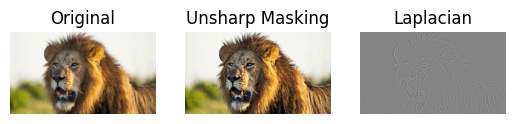

In [32]:
blurred = cv2.GaussianBlur(img, (9, 9), 10)
unsharp = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
laplacian = cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F)
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(unsharp, cv2.COLOR_BGR2RGB))
plt.title('Unsharp Masking')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')
plt.show()

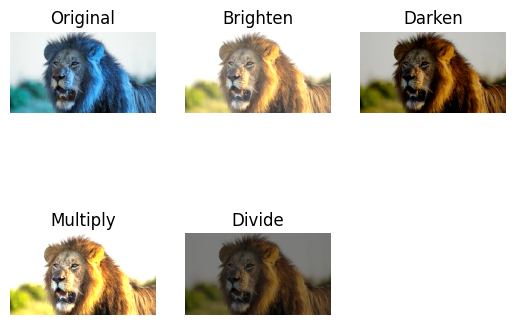

In [34]:
bright = cv2.add(img, 50)
dark = cv2.subtract(img, 50)
mult = cv2.multiply(img, 1.5)
div = cv2.divide(img, 2)
titles = ['Original', 'Brighten', 'Darken', 'Multiply', 'Divide']
images = [img_rgb, bright, dark, mult, div]
for i in range(5):
  plt.subplot(2, 3, i+1)
  plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
  plt.title(titles[i])
  plt.axis('off')
plt.show()

/tmp/ipython-input-35-3606040766.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0, 256])


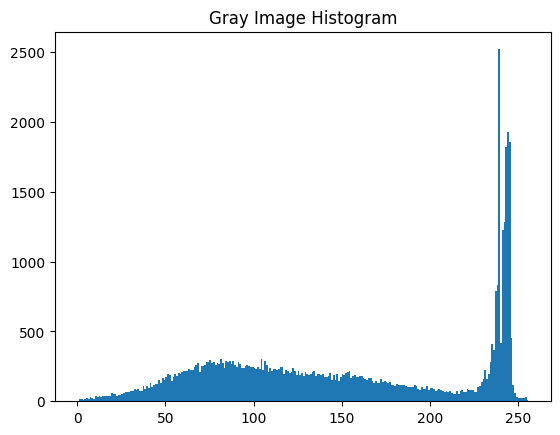

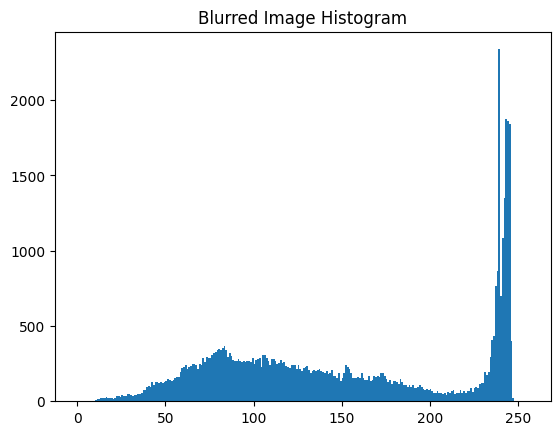

/tmp/ipython-input-35-3606040766.py:2: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(image.ravel(), 256, [0, 256])


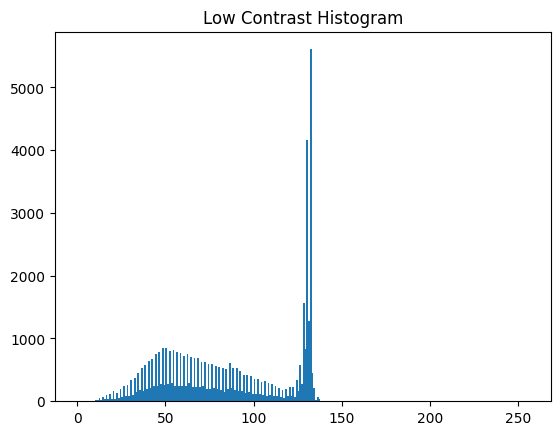

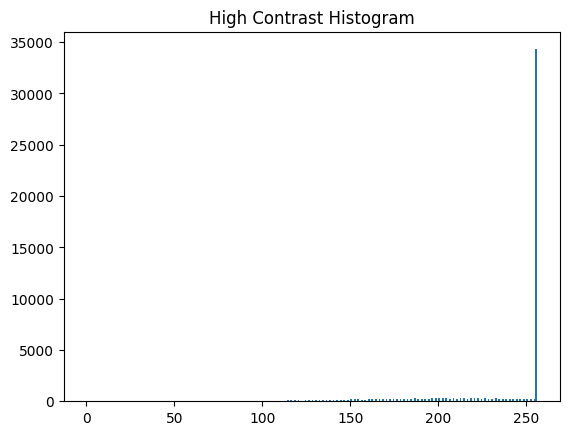

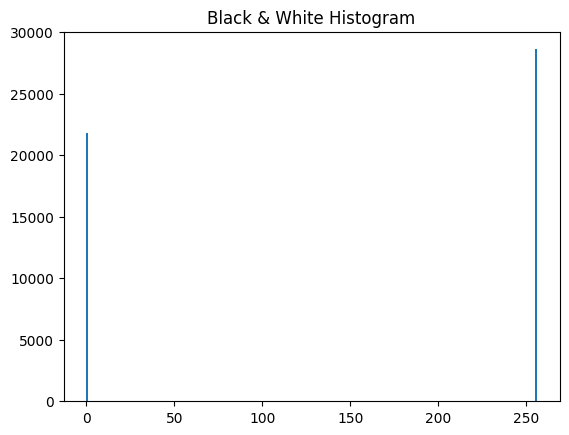

In [35]:
def plot_hist(image, title):
  plt.hist(image.ravel(), 256, [0, 256])
  plt.title(title)
  plt.show()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 0)
low_contrast = cv2.convertScaleAbs(gray, alpha=0.5, beta=10)
high_contrast = cv2.convertScaleAbs(gray, alpha=2, beta=50)
bw = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)[1]
plot_hist(gray, 'Gray Image Histogram')
plot_hist(blurred, 'Blurred Image Histogram')
plot_hist(low_contrast, 'Low Contrast Histogram')
plot_hist(high_contrast, 'High Contrast Histogram')
plot_hist(bw, 'Black & White Histogram')

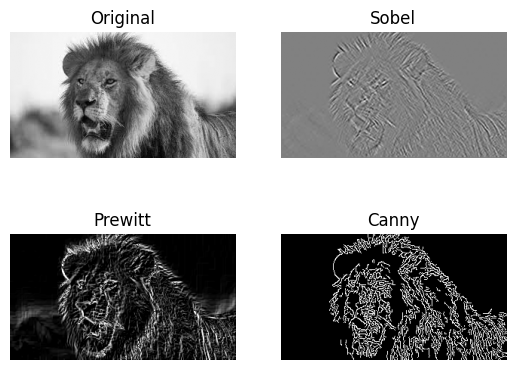

In [36]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sobel = cv2.Sobel(gray, cv2.CV_64F, 1, 1, ksize=5)
prewitt_x = cv2.filter2D(gray, -1, np.array([[1,0,-1],[1,0,-1],[1,0,-1]]))
prewitt_y = cv2.filter2D(gray, -1, np.array([[1,1,1],[0,0,0],[-1,-1,-1]]))
prewitt = prewitt_x + prewitt_y
canny = cv2.Canny(gray, 100, 200)
titles = ['Original', 'Sobel', 'Prewitt', 'Canny']
images = [gray, sobel, prewitt, canny]
for i in range(4):
  plt.subplot(2, 2, i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
plt.show()